# <font color="teal">**Chase Dollander: How his talents didn't lead to success in 2025**</font>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

## <font color="teal">**Import date, downloaded using pybaseball**</font>

In [ ]:
## map to Data

df_path = "data/mlb_2025_sample.csv"

Mounted at /content/drive


In [ ]:
df = pd.read_csv(df_path)

#Regular season games
df = df[df['game_type'] == 'R']


## <font color="teal">**Data cleaning**</font>

In [ ]:
## grab all entries were player_name is "Dollander, Chase"

df_chase = df[df['player_name'] == "Dollander, Chase"]
df['coors'] = (df['home_team'] == 'COL').astype(int)

In [ ]:
## Combine balls and strikes into one column

df_chase["Count"] = (
    df_chase["balls"].astype(str)
    + "-"
    + df_chase["strikes"].astype(str)
)

/tmp/ipykernel_8636/2255323978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chase["Count"] = (


In [ ]:
## add 'barrel' column

# Calculate speed difference (only positive deltas matter)
delta = np.maximum(0, df_chase['launch_speed'] - 99)

# Dynamic angle bounds
lower_bound = 26 - 2 * delta
upper_bound = 30 + 2 * delta

# Create barrel column
df_chase['barrel'] = (
    (df_chase['launch_speed'] >= 99) &
    (df_chase['launch_angle'] >= lower_bound) &
    (df_chase['launch_angle'] <= upper_bound)
).astype(int)

/tmp/ipykernel_8636/1561828712.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chase['barrel'] = (


In [ ]:
# Create Binary column for pitch success

df_chase['pitch_success'] = (
    df_chase['description'].isin([
        'foul','called_strike','swinging_strike',
        'foul_tip','swinging_strike_blocked','foul_bunt',
        'missed_bunt','bunt_foul_tip'
    ]) |
    ((df_chase['description'] == 'hit_into_play') & (df_chase['estimated_woba_using_speedangle'] >= .100))
).astype(int)

/tmp/ipykernel_8636/4208418923.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chase['pitch_success'] = (


## <font color="teal">**Determine barrel rate by count**</font>

In [ ]:
success_by_count = (
    df_chase
    .groupby("Count")["barrel"]
    .mean()
    .reset_index()
    .rename(columns={"barrel": "barrel_rate"})
)

success_by_count

,Count,barrel_rate
0,0-0,0.013544
1,0-1,0.015000
2,0-2,0.009091
3,1-0,0.031250
4,1-1,0.012048
5,1-2,0.038217
6,2-0,0.051948
7,2-1,0.038462
8,2-2,0.027972
9,3-0,0.000000


In [ ]:
df_chase_x = df_chase[df_chase['description'] == 'hit_into_play']

## <font color="teal">**Determine barrel rate by pitch**</font>

In [ ]:
barrel_by_type = (
    df_chase_x
    .groupby("pitch_type")["barrel"]
    .mean()
    .reset_index()
    .rename(columns={"barrel": "barrel_rate"})
)

barrel_by_type

,pitch_type,barrel_rate
0,CH,0.033333
1,CU,0.086207
2,FC,0.216216
3,FF,0.141791
4,SI,0.088889


## <font color="teal">**Whats going on with the Cutter?**</font>

In [ ]:
df_chase_FC = df_chase_x[df_chase_x['pitch_type'] == 'FC']

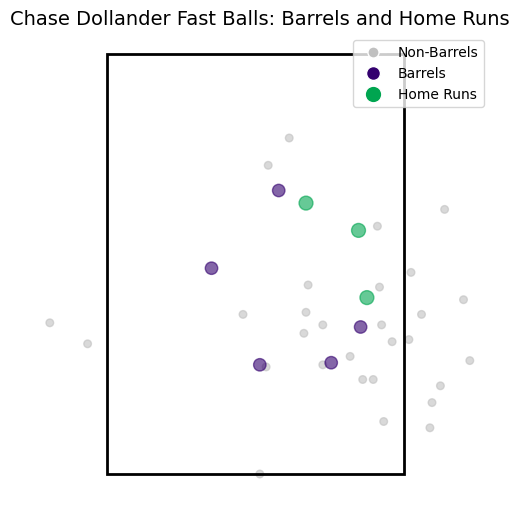

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.lines import Line2D

# Colors
coors_color = "#33006F"   # Purple for barrels
other_color = "#C0C0C0"   # Gray for non-barrels
hr_color = "#00A550"      # Rockies green for home runs

# Map colors
colors = np.where(df_chase_FC['barrel'] == 1, coors_color, other_color)
colors = np.where(df_chase_FC['events'] == 'home_run', hr_color, colors)

# Sizes
sizes = np.where(df_chase_FC['barrel'] == 1, 80, 30)
sizes = np.where(df_chase_FC['events'] == 'home_run', 100, sizes)

plt.figure(figsize=(6,6))

# Scatter
plt.scatter(
    df_chase_FC['plate_x'],
    df_chase_FC['plate_z'],
    c=colors,
    s=sizes,
    alpha=0.6
)

# Strike zone
plate_half_width = 17 / 12 / 2
zone_bottom = 1.5
zone_top = 3.5
strike_zone = patches.Rectangle(
    (-plate_half_width, zone_bottom),
    2 * plate_half_width,
    zone_top - zone_bottom,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
plt.gca().add_patch(strike_zone)

# No axes
plt.axis('off')
plt.gca().set_aspect('equal', adjustable='box')

# ---- Title ----
plt.title("Chase Dollander Fast Balls: Barrels and Home Runs", fontsize=14)

# ---- Legend ----
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Non-Barrels',
           markerfacecolor=other_color, markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Barrels',
           markerfacecolor=coors_color, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Home Runs',
           markerfacecolor=hr_color, markersize=12)
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

## <font color="teal">**Slugging by pitch location - Balls in play**</font>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize

def plot_slg_heatmap(df, player_name, pitch_type, stand=None, coors_filter=None):
    """
    Plot a plate heat map for a player and pitch type,
    coloring points by estimated SLG on contact.

    Only includes pitches where description == 'hit_into_play'.

    Parameters:
        df : pd.DataFrame
        player_name : str
        pitch_type : str
    """

    # Ensure stand is always a list
    if stand is None:
        stand = ["R","L"]
    elif isinstance(stand, str):
        stand = [stand]

    # Handle coors
    if coors_filter is None:
        coors_filter = [0,1]
    elif isinstance(coors_filter, int):
        coors_filter = [coors_filter]

    # Filter data
    df_plot = df[
        (df['player_name'] == player_name) &
        (df['pitch_type'] == pitch_type) &
        (df['description'] == 'hit_into_play') &
        (df['stand'].isin(stand)) &
        (df['coors'].isin(coors_filter))
    ]


    if df_plot.empty:
        print(f"No data for {player_name} / {pitch_type} with hit_into_play")
        return

    plt.figure(figsize=(6,6))

    # Normalize SLG for color intensity
    norm = Normalize(vmin=df_plot['estimated_slg_using_speedangle'].min(),
                     vmax=df_plot['estimated_slg_using_speedangle'].max())


    # Scatter
    scatter = plt.scatter(
        df_plot['plate_x'],
        df_plot['plate_z'],
        c=df_plot['estimated_slg_using_speedangle'],
        cmap='Purples',
        norm=norm,
        s=60,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.1
    )

    # Colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Expected SLG", fontsize=10)

    # Zone slug style
    text_style = dict(
    ha='left',
    va='top',
    fontsize=10,
    fontstyle='italic',
    color='darkgreen'
    )

    # Strike zone
    plate_half_width = 17 / 12 / 2
    zone_bottom = 1.5
    zone_top = 3.5
    strike_zone = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width,
        zone_top - zone_bottom,
        linewidth=2,
        edgecolor='Black',
        facecolor='none'
    )

    zone1 = patches.Rectangle(
        (-plate_half_width, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone2 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone3 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone4 = patches.Rectangle(
        (-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone5 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone6 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone7 = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone8 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone9 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )


    # Collect Zone slugs
    zone_slugs = {}

    for i in range(1, 15):
        avg_slg = (
            df_plot[df_plot["zone"] == i]["estimated_slg_using_speedangle"].mean()
        )
        zone_slugs[i] = round(avg_slg, 3)

    plt.gca().add_patch(strike_zone)
    plt.gca().add_patch(zone1)
    plt.gca().add_patch(zone2)
    plt.gca().add_patch(zone3)
    plt.gca().add_patch(zone4)
    plt.gca().add_patch(zone5)
    plt.gca().add_patch(zone6)
    plt.gca().add_patch(zone7)
    plt.gca().add_patch(zone8)
    plt.gca().add_patch(zone9)

    plt.text(
    -plate_half_width + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[1]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width / 3 + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[2]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width / 3  + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[3]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.10 +  zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[4]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.10 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[5]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.10 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[6]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.10 + zone_bottom,
    f"{zone_slugs[7]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.10 + zone_bottom,
    f"{zone_slugs[8]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.10 + zone_bottom,
    f"{zone_slugs[9]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width, zone_bottom - 0.20,
    "xSLG by zone",
    **text_style
    )

    # Formatting
    # Stand label
    if stand == ["R", "L"]:
        stand_label = "RHH & LHH"
    elif stand == ["R"]:
        stand_label = "RHH"
    elif stand == ["L"]:
        stand_label = "LHH"
    else:
        stand_label = "Mixed"

    # Coors label
    if coors_filter == [0,1]:
        coors_label = "All Parks"
    elif coors_filter == [1]:
        coors_label = "Coors Field"
    elif coors_filter == [0]:
        coors_label = "Non-Coors"
    else:
        coors_label = ""

    # Pitching label
    if pitch_type == "FF":
        pitch_type = "Fastball"
    elif pitch_type == "CU":
        pitch_type = "Curveball"

    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{player_name} - {pitch_type} \n {stand_label} | {coors_label} | xSLG Heat Map", fontsize=14)

    plt.show()

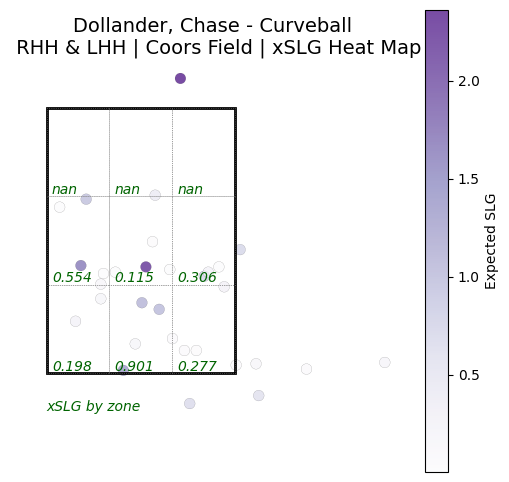

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "CU", None, 1)

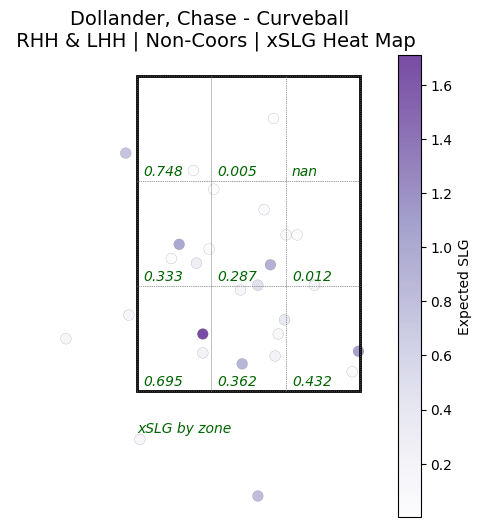

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "CU", None, 0)

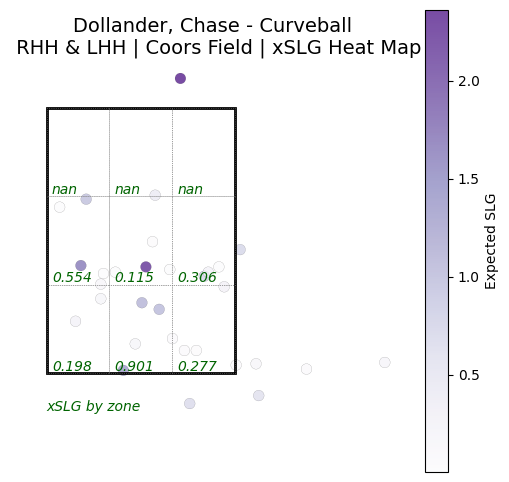

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "CU", None, 1)

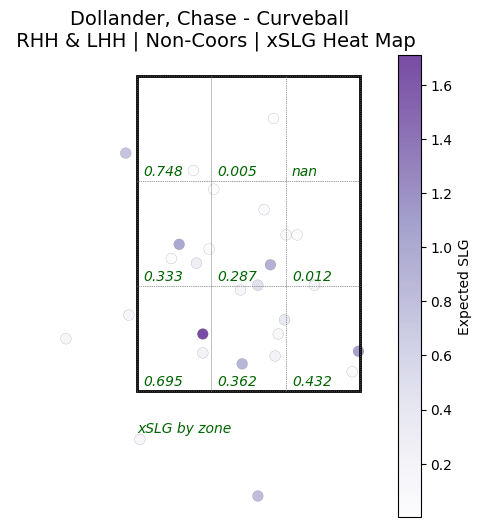

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "CU", None, 0)

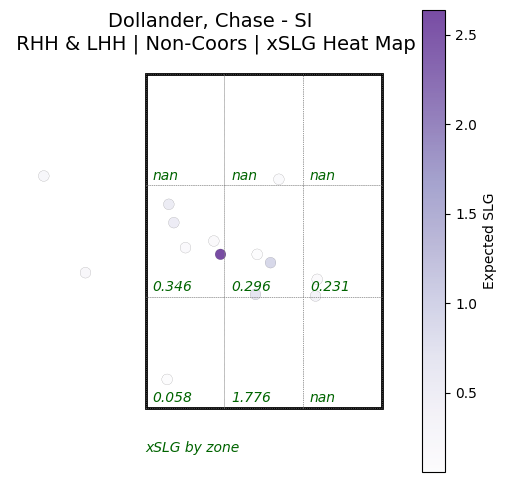

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "SI", None, 0)

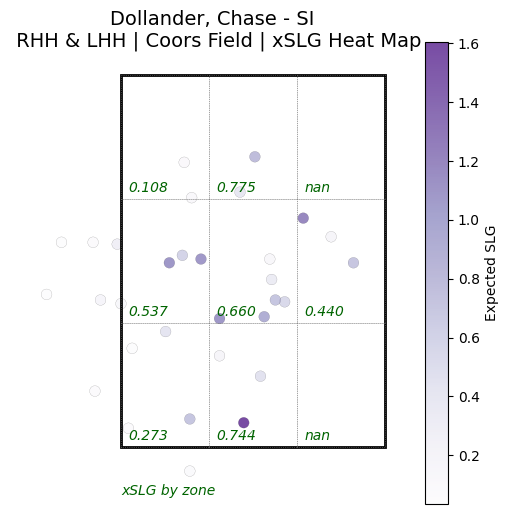

In [ ]:
plot_slg_heatmap(df, "Dollander, Chase", "SI", None, 1)

In [ ]:
avg_xslg_by_zone = (
    df_chase
    .groupby("zone")["estimated_slg_using_speedangle"]
    .agg(avg_xslg="mean", n="size")
    .reset_index()
)

avg_xslg_by_zone

,zone,avg_xslg,n
0,1.0,0.543931,90
1,2.0,0.690712,110
2,3.0,0.379125,58
3,4.0,0.458087,121
4,5.0,0.821644,139
5,6.0,0.514797,134
6,7.0,0.470590,56
7,8.0,0.836888,97
8,9.0,0.490179,96
9,11.0,0.260909,219


## <font color="teal">**Whiffs by pitch location - All Pitches**</font>

In [ ]:
## Add Whiff column if 'description' is foul_tip, swinging_strike_blocked, swinging_strike

df['whiff'] = (
    df['description'].isin([
        'foul_tip','swinging_strike_blocked','swinging_strike'
    ])
).astype(int)




df['whiff'].value_counts()

,count
whiff,
0,3134644
1,432996


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon

def plot_whiffs(df, player_name, pitch_type, stand=None, coors_filter=None):
    """
    Plot a plate heat map for a player and pitch type,
    coloring points by estimated SLG on contact.

    Only includes pitches where description == 'hit_into_play'.

    Parameters:
        df : pd.DataFrame
        player_name : str
        pitch_type : str
    """

    # Ensure stand is always a list
    if stand is None:
        stand = ["R","L"]
    elif isinstance(stand, str):
        stand = [stand]

    # Handle coors
    if coors_filter is None:
        coors_filter = [0,1]
    elif isinstance(coors_filter, int):
        coors_filter = [coors_filter]

    # Filter data
    df_plot = df[
        (df['player_name'] == player_name) &
        (df['pitch_type'] == pitch_type) &
        (df['plate_x'] > -2) & (df['plate_x'] < 2) &
        (df['plate_z'] > 1) & (df['plate_z'] < 4) &
        (df['stand'].isin(stand)) &
        (df['coors'].isin(coors_filter))
    ]


    if df_plot.empty:
        print(f"No data for {player_name} / {pitch_type}")
        return

    plt.figure(figsize=(8,8))

    cmap = ListedColormap(['lightgrey', 'purple'])

    # Scatter
    scatter = plt.scatter(
        df_plot['plate_x'],
        df_plot['plate_z'],
        c=df_plot['whiff'],
        cmap=cmap,
        s=60,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.1
    )


    # Zone whiff style
    text_style = dict(
    ha='left',
    va='top',
    fontsize=12,
    fontstyle='italic',
    fontweight='bold',
    color='darkgreen'
    )

    # Strike zone
    plate_half_width = 17 / 12 / 2
    zone_bottom = 1.5
    zone_top = 3.5
    strike_zone = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width,
        zone_top - zone_bottom,
        linewidth=2,
        edgecolor='Black',
        facecolor='none'
    )

    zone1 = patches.Rectangle(
        (-plate_half_width, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone2 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone3 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone4 = patches.Rectangle(
        (-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone5 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone6 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone7 = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone8 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone9 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    # Outside Zones
    zone11_coords = [
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom)],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom)],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone11 = Polygon(zone11_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone12_coords = [
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom)],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom)],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone12 = Polygon(zone12_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone13_coords = [
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [plate_half_width + .2, zone_bottom - .2],
        [0, zone_bottom - .2],
        [0, zone_bottom],
        [plate_half_width, zone_bottom],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone13 = Polygon(zone13_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone14_coords = [
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [-plate_half_width - .2, zone_bottom - .2],
        [0, zone_bottom - .2],
        [0, zone_bottom],
        [-plate_half_width, zone_bottom],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone14 = Polygon(zone14_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    # Collect Zone Whiffs
    zone_whiff_perc = {}

    for i in range(1, 15):
        avg_slg = (
            df_plot[df_plot["zone"] == i]["whiff"].mean()
        )
        zone_whiff_perc[i] = round(avg_slg, 3)

    plt.gca().add_patch(strike_zone)
    plt.gca().add_patch(zone1)
    plt.gca().add_patch(zone2)
    plt.gca().add_patch(zone3)
    plt.gca().add_patch(zone4)
    plt.gca().add_patch(zone5)
    plt.gca().add_patch(zone6)
    plt.gca().add_patch(zone7)
    plt.gca().add_patch(zone8)
    plt.gca().add_patch(zone9)
    plt.gca().add_patch(zone11)
    plt.gca().add_patch(zone12)
    plt.gca().add_patch(zone13)
    plt.gca().add_patch(zone14)

    plt.text(
    -plate_half_width + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[1]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width / 3 + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[2]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width / 3  + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[3]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.12 +  zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[4]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.12 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[5]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.12 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[6]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.12 + zone_bottom,
    f"{zone_whiff_perc[7]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.12 + zone_bottom,
    f"{zone_whiff_perc[8]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.12 + zone_bottom,
    f"{zone_whiff_perc[9]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.15, zone_top + 0.15,
    f"{zone_whiff_perc[11]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width - 0.19, zone_top + 0.15,
    f"{zone_whiff_perc[12]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.15, zone_bottom - 0.08,
    f"{zone_whiff_perc[13]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width - 0.18, zone_bottom - 0.08,
    f"{zone_whiff_perc[14]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.20, zone_bottom - 0.40,
    "Whiff % by zone",
    **text_style
    )



    # Formatting
    # Stand label
    if stand == ["R", "L"]:
        stand_label = "RHH & LHH"
    elif stand == ["R"]:
        stand_label = "RHH"
    elif stand == ["L"]:
        stand_label = "LHH"
    else:
        stand_label = "Mixed"

    # Coors label
    if coors_filter == [0,1]:
        coors_label = "All Parks"
    elif coors_filter == [1]:
        coors_label = "Coors Field"
    elif coors_filter == [0]:
        coors_label = "Non-Coors"
    else:
        coors_label = ""

    # Pitching label
    if pitch_type == "FF":
        pitch_type = "Fastball"
    elif pitch_type == "CU":
        pitch_type = "Curveball"


    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{player_name} - {pitch_type} \n {stand_label} | {coors_label} | Whiffs by zone", fontsize=14)

    plt.show()

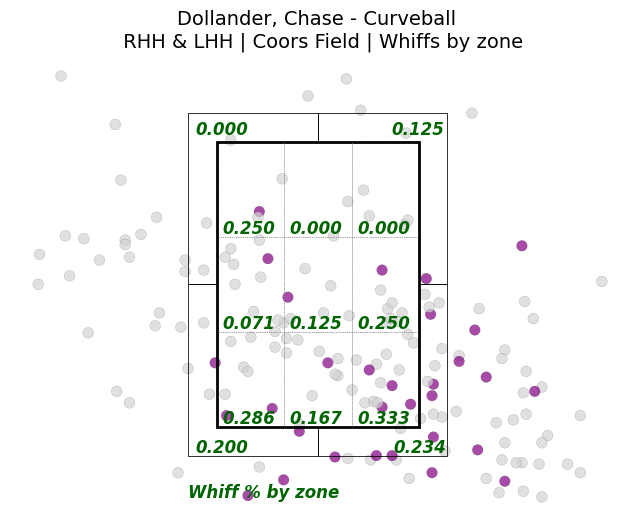

In [ ]:
plot_whiffs(df, "Dollander, Chase", "CU", None, 1)

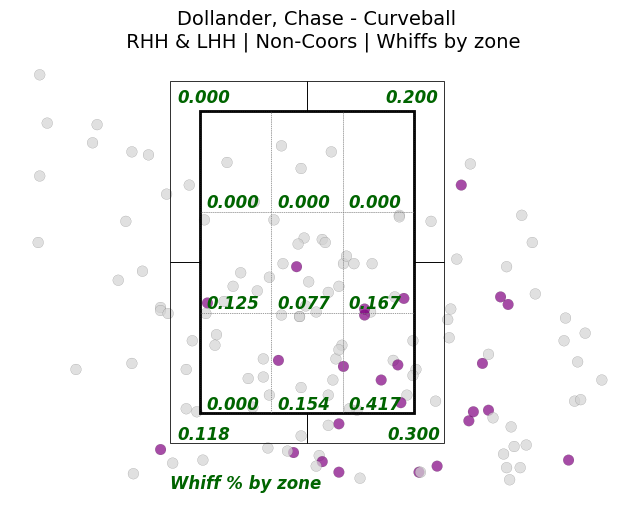

In [ ]:
plot_whiffs(df, "Dollander, Chase", "CU", None, 0)

In [ ]:
df['stand'].value_counts()

,count
stand,
R,2067464
L,1500176


In [ ]:
avg_whiff_by_zone = (
    df
    .groupby("zone")['whiff']
    .agg(avg_xslg="mean", n="size")
    .reset_index()
)

avg_whiff_by_zone

,zone,avg_xslg,n
0,1.0,0.141201,150254
1,2.0,0.168160,181292
2,3.0,0.147173,134420
3,4.0,0.084408,212337
4,5.0,0.096740,266591
5,6.0,0.100277,215254
6,7.0,0.116101,170153
7,8.0,0.115830,226392
8,9.0,0.135524,198541
9,11.0,0.075243,391985


## <font color="teal">**Simple Stats by pitch type**</font>

In [ ]:
df[['events', 'description']].head()

,events,description
10581,field_out,hit_into_play
10582,NaN,foul
10583,NaN,foul
10584,NaN,ball
10585,field_out,hit_into_play


In [ ]:
df['events'].value_counts()

,count
events,
field_out,365204
strikeout,206076
single,128930
walk,74057
double,39547
home_run,28130
force_out,17994
grounded_into_double_play,16483
hit_by_pitch,10217


## <font color="teal">**Gather home/run splits**</font>

In [ ]:
def pitcher_splits(df, player_name, stand=None, pitch_type=None, ):
    # Remove pitches not resulting in event
    df = df[df['events'].notna()]
    df = df[df['events'] != 'truncated_pa']

    # Handle stand
    if stand is None:
        stand = ["R","L"]

    # Ensure stand is always a list
    if stand is None:
        stand = ["R","L"]
    elif isinstance(stand, str):
        stand = [stand]

    # Base filter
    base_filter = (
        (df['player_name'] == player_name) &
        (df['stand'].isin(stand))
    )

    # Optionally filter by pitch_type if provided
    if pitch_type is not None:
        base_filter &= (df['pitch_type'] == pitch_type)

    # Split by home/road
    df_splits_home = df[base_filter & (df['coors'] == 1)]
    df_splits_road = df[base_filter & (df['coors'] == 0)]

    ## Batting Average
    hit = ['single', 'double', 'triple', 'home_run']
    non_at_bat = ['walk', 'hit_by_pitch', 'sac_fly', 'intent_walk', 'sac_bunt', 'catcher_interf', 'sac_bunt_double_play', 'truncated_pa', 'sac_fly_double_play']


    batting_avg_home = (
      df_splits_home[df_splits_home['events'].isin(hit)].shape[0] /
      df_splits_home[~df_splits_home['events'].isin(non_at_bat)].shape[0]
    )

    batting_avg_road = (
        df_splits_road[df_splits_road['events'].isin(hit)].shape[0] /
        df_splits_road[~df_splits_road['events'].isin(non_at_bat)].shape[0]
    )

    ## On Base percentage
    on_base = ['single', 'double', 'triple', 'home_run', 'walk', 'intent_walk', 'hit_by_pitch']
    obp_denominator_extra = ['sac_bunt', 'catcher_interf', 'sac_bunt_double_play', 'truncated_pa']

    on_base_per_home = (
        df_splits_home[df_splits_home['events'].isin(on_base)].shape[0] /
        df_splits_home[~df_splits_home['events'].isin(obp_denominator_extra)].shape[0]
    )

    on_base_per_road = (
        df_splits_road[df_splits_road['events'].isin(on_base)].shape[0] /
        df_splits_road[~df_splits_road['events'].isin(obp_denominator_extra)].shape[0]
    )

    ## Slugging Percentage
    slugging = {'single': 1, 'double': 2, 'triple': 3, 'home_run': 4}

    slugging_numerator_home = sum(df_splits_home['events'].map(slugging).fillna(0))
    slugging_numerator_road = sum(df_splits_road['events'].map(slugging).fillna(0))

    slgging_per_home = (
        slugging_numerator_home /
        df_splits_home[~df_splits_home['events'].isin(non_at_bat)].shape[0]
    )

    slgging_per_road = (
        slugging_numerator_road /
        df_splits_road[~df_splits_road['events'].isin(non_at_bat)].shape[0]
    )

    return {
        'batting_avg_home': batting_avg_home,
        'batting_avg_road': batting_avg_road,
        'obp_home': on_base_per_home,
        'obp_road': on_base_per_road,
        'slugging_home': slgging_per_home,
        'slugging_road': slgging_per_road
    }


In [ ]:
pitcher_splits(df, "Dollander, Chase")

{'batting_avg_home': 0.336734693877551,
 'batting_avg_road': 0.2,
 'obp_home': 0.4166666666666667,
 'obp_road': 0.2971698113207547,
 'slugging_home': 0.576530612244898,
 'slugging_road': 0.32432432432432434}

In [ ]:
df_chase['game_type'].value_counts()

,count
game_type,
R,1778


## <font color="teal">**Calculate euclidean difference delta between home and road parks**</font>

In [ ]:
import pandas as pd
import numpy as np

def pitch_movement_delta(player_name, df):
    """
    Compute Euclidean distance between mean pfx_x / pfx_z at Coors vs Other Parks
    for each pitch type for a given pitcher.

    Returns a DataFrame with pitch_type, coors_mean_x, coors_mean_z, other_mean_x,
    other_mean_z, and euclidean_delta.
    """

    pitcher_df = df[df['player_name'] == player_name].copy()
    if pitcher_df.empty:
        print(f"No data for {player_name}")
        return None

    # Convert to inches and flip horizontal to match Savant orientation
    pitcher_df['pfx_x_plot'] = -pitcher_df['pfx_x'] * 12
    pitcher_df['pfx_z_plot'] = pitcher_df['pfx_z'] * 12

    results = []

    for pitch, group in pitcher_df.groupby('pitch_type'):
        coors = group[group['coors'] == 1]
        other = group[group['coors'] == 0]

        if len(coors) < 5 or len(other) < 5:
            continue  # skip if not enough samples

        coors_mean_x = coors['pfx_x_plot'].mean()
        coors_mean_z = coors['pfx_z_plot'].mean()

        other_mean_x = other['pfx_x_plot'].mean()
        other_mean_z = other['pfx_z_plot'].mean()

        euclidean_delta = np.sqrt(
            (coors_mean_x - other_mean_x)**2 + (coors_mean_z - other_mean_z)**2
        )

        results.append({
            'pitch_type': pitch,
            'coors_mean_x': coors_mean_x,
            'coors_mean_z': coors_mean_z,
            'other_mean_x': other_mean_x,
            'other_mean_z': other_mean_z,
            'euclidean_delta': euclidean_delta
        })

    return pd.DataFrame(results).sort_values('euclidean_delta', ascending=False)

In [ ]:
pitch_movement_delta("Dollander, Chase", df)

,pitch_type,coors_mean_x,coors_mean_z,other_mean_x,other_mean_z,euclidean_delta
0,CH,13.674627,4.508060,17.596056,4.673239,3.924907
4,SI,13.933469,4.348163,17.532308,5.600000,3.810345
3,FF,10.066729,11.276612,12.799091,13.492364,3.517862
1,CU,-12.747136,-6.686834,-15.374667,-8.138667,3.001955
2,FC,-4.232542,3.225763,-4.063529,4.235294,1.023581


## <font color="teal">**Calculate pitch specific home/road metrics**</font>

In [ ]:
def savant_pitch_metrics(df, player_name, pitch_type=None, stand=None):

    df = df[df['player_name'] == player_name]

    # handle batter handedness
    if stand is not None:
        if isinstance(stand, str):
            stand = [stand]
        df = df[df['stand'].isin(stand)]

    # handle pitch type
    if pitch_type is not None:
        df = df[df['pitch_type'] == pitch_type]

    # terminal pitches (end of PA)
    pa_df = df[df['events'].notna()].copy()

    # Split by home/road
    df_splits_home = pa_df[pa_df['coors'] == 1]
    df_splits_road = pa_df[pa_df['coors'] == 0]

    # event groups
    hits = ['single','double','triple','home_run']

    ab_events = [
        'single','double','triple','home_run',
        'field_out','force_out','grounded_into_double_play',
        'field_error','fielders_choice','strikeout', 'double_play',
        'fielders_choice_out', 'strikeout_double_play', 'triple_play'
    ]

    bip_events = [
        'single','double','triple','home_run',
        'field_out','force_out','grounded_into_double_play',
        'field_error','fielders_choice', 'double_play',
        'fielders_choice_out', 'triple_play'
    ]

    walk_events = ['walk','intent_walk']
    hbp_events = ['hit_by_pitch']
    sac_events = ['sac_fly']

    # AB
    ab_df_home = df_splits_home[df_splits_home['events'].isin(ab_events)]
    AB_home = len(ab_df_home)
    ab_df_road = df_splits_road[df_splits_road['events'].isin(ab_events)]
    AB_road = len(ab_df_road)

    # hits
    H_home = df_splits_home[df_splits_home['events'].isin(hits)].shape[0]
    H_road = df_splits_road[df_splits_road['events'].isin(hits)].shape[0]

    # total bases
    bases = {'single':1,'double':2,'triple':3,'home_run':4}
    TB_home = df_splits_home['events'].map(bases).fillna(0).sum()
    TB_road = df_splits_road['events'].map(bases).fillna(0).sum()

    # walks / hbp / sac
    BB_home = df_splits_home[df_splits_home['events'].isin(walk_events)].shape[0]
    BB_road = df_splits_road[df_splits_road['events'].isin(walk_events)].shape[0]

    HBP_home = df_splits_home[df_splits_home['events'].isin(hbp_events)].shape[0]
    HBP_road = df_splits_road[df_splits_road['events'].isin(hbp_events)].shape[0]

    SF_home = df_splits_home[df_splits_home['events'].isin(sac_events)].shape[0]
    SF_road = df_splits_road[df_splits_road['events'].isin(sac_events)].shape[0]

    # PA
    PA_home = AB_home + BB_home + HBP_home + SF_home
    PA_road = AB_road + BB_road + HBP_road + SF_road

    # BIP
    bip_df_home = df_splits_home[df_splits_home['events'].isin(bip_events)]
    bip_df_road = df_splits_road[df_splits_road['events'].isin(bip_events)]
    BIP_home = len(bip_df_home)
    BIP_road = len(bip_df_road)

    #Expected Stats
    xBA_tot_home = df_splits_home['estimated_ba_using_speedangle'].sum()
    xBA_tot_road = df_splits_road['estimated_ba_using_speedangle'].sum()

    xSLG_tot_home = df_splits_home['estimated_slg_using_speedangle'].sum()
    xSLG_tot_road = df_splits_road['estimated_slg_using_speedangle'].sum()

    xBA_home = xBA_tot_home / AB_home if AB_home else None
    xBA_road = xBA_tot_road / AB_road if AB_road else None

    xSLG_home = xSLG_tot_home / AB_home if AB_home else None
    xSLG_road = xSLG_tot_road / AB_road if AB_road else None

    # final metrics
    BA_home = H_home / AB_home if AB_home else None
    BA_road = H_road / AB_road if AB_road else None
    SLG_home = TB_home / AB_home if AB_home else None
    SLG_road = TB_road / AB_road if AB_road else None

    print(f"Home BA: {BA_home:.3f}")
    print(f"Home SLG: {SLG_home:.3f}")
    print(f"Home xBA: {xBA_home:.3f}")
    print(f"Home xSLG: {xSLG_home:.3f}")
    print(".....................")
    print(f"Road BA: {BA_road:.3f}")
    print(f"Road SLG: {SLG_road:.3f}")
    print(f"Road xBA: {xBA_road:.3f}")
    print(f"Road xSLG: {xSLG_road:.3f}")

In [ ]:
savant_pitch_metrics(df, "Dollander, Chase", "CU")

Home BA: 0.167
Home SLG: 0.229
Home xBA: 0.188
Home xSLG: 0.325
.....................
Road BA: 0.154
Road SLG: 0.179
Road xBA: 0.160
Road xSLG: 0.253


## <font color="teal">**Create heat map, visualizing slugging percentage by zone**</font>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize

def plot_slg_heatmap_comp(df, player_name, pitch_type, stand=None, coors_filter=None):
    """
    Plot a plate heat map for a player and pitch type,
    coloring points by estimated SLG on contact.

    Only includes pitches where description == 'hit_into_play'.

    Parameters:
        df : pd.DataFrame
        player_name : str
        pitch_type : str
    """

    # Ensure stand is always a list
    if stand is None:
        stand = ["R","L"]
    elif isinstance(stand, str):
        stand = [stand]

    # Handle coors
    if coors_filter is None:
        coors_filter = [0,1]
    elif isinstance(coors_filter, int):
        coors_filter = [coors_filter]

    # Filter data
    df_plot = df[
        (df['player_name'] == player_name) &
        (df['pitch_type'] == pitch_type) &
        (df['description'] == 'hit_into_play') &
        (df['stand'].isin(stand)) &
        (df['coors'].isin(coors_filter))
    ]


    if df_plot.empty:
        print(f"No data for {player_name} / {pitch_type} with hit_into_play")
        return

    # Normalize SLG for color intensity
    norm = Normalize(vmin=0.0, vmax=4.0)


    # Scatter
    scatter = plt.scatter(
        df_plot['plate_x'],
        df_plot['plate_z'],
        c=df_plot['estimated_slg_using_speedangle'],
        cmap='Purples',
        norm=norm,
        s=60,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.1
    )

    # Colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label("Expected SLG", fontsize=10)

    # Zone slug style
    text_style = dict(
    ha='left',
    va='top',
    fontsize=10,
    fontstyle='italic',
    color='darkgreen'
    )

    # Strike zone
    plate_half_width = 17 / 12 / 2
    zone_bottom = 1.5
    zone_top = 3.5
    strike_zone = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width,
        zone_top - zone_bottom,
        linewidth=2,
        edgecolor='Black',
        facecolor='none'
    )

    zone1 = patches.Rectangle(
        (-plate_half_width, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone2 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone3 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone4 = patches.Rectangle(
        (-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone5 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone6 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone7 = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone8 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone9 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )


    # Collect Zone slugs
    zone_slugs = {}

    for i in range(1, 15):
        avg_slg = (
            df_plot[df_plot["zone"] == i]["estimated_slg_using_speedangle"].mean()
        )
        zone_slugs[i] = round(avg_slg, 3)

    plt.gca().add_patch(strike_zone)
    plt.gca().add_patch(zone1)
    plt.gca().add_patch(zone2)
    plt.gca().add_patch(zone3)
    plt.gca().add_patch(zone4)
    plt.gca().add_patch(zone5)
    plt.gca().add_patch(zone6)
    plt.gca().add_patch(zone7)
    plt.gca().add_patch(zone8)
    plt.gca().add_patch(zone9)

    plt.text(
    -plate_half_width + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[1]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width / 3 + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[2]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width / 3  + 0.04, 0.10 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_slugs[3]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.10 +  zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[4]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.10 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[5]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.10 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_slugs[6]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.10 + zone_bottom,
    f"{zone_slugs[7]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.10 + zone_bottom,
    f"{zone_slugs[8]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.10 + zone_bottom,
    f"{zone_slugs[9]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width, zone_bottom - 0.20,
    "xSLG by zone",
    **text_style
    )

    # Formatting
    # Stand label
    if stand == ["R", "L"]:
        stand_label = "RHH & LHH"
    elif stand == ["R"]:
        stand_label = "RHH"
    elif stand == ["L"]:
        stand_label = "LHH"
    else:
        stand_label = "Mixed"

    # Coors label
    if coors_filter == [0,1]:
        coors_label = "All Parks"
    elif coors_filter == [1]:
        coors_label = "Coors Field"
    elif coors_filter == [0]:
        coors_label = "Non-Coors"
    else:
        coors_label = ""

    # Pitching label
    if pitch_type == "FF":
        pitch_type = "Fastball"
    elif pitch_type == "CU":
        pitch_type = "Curveball"

    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{player_name} - {pitch_type} \n {stand_label} | {coors_label} | xSLG Heat Map", fontsize=14)

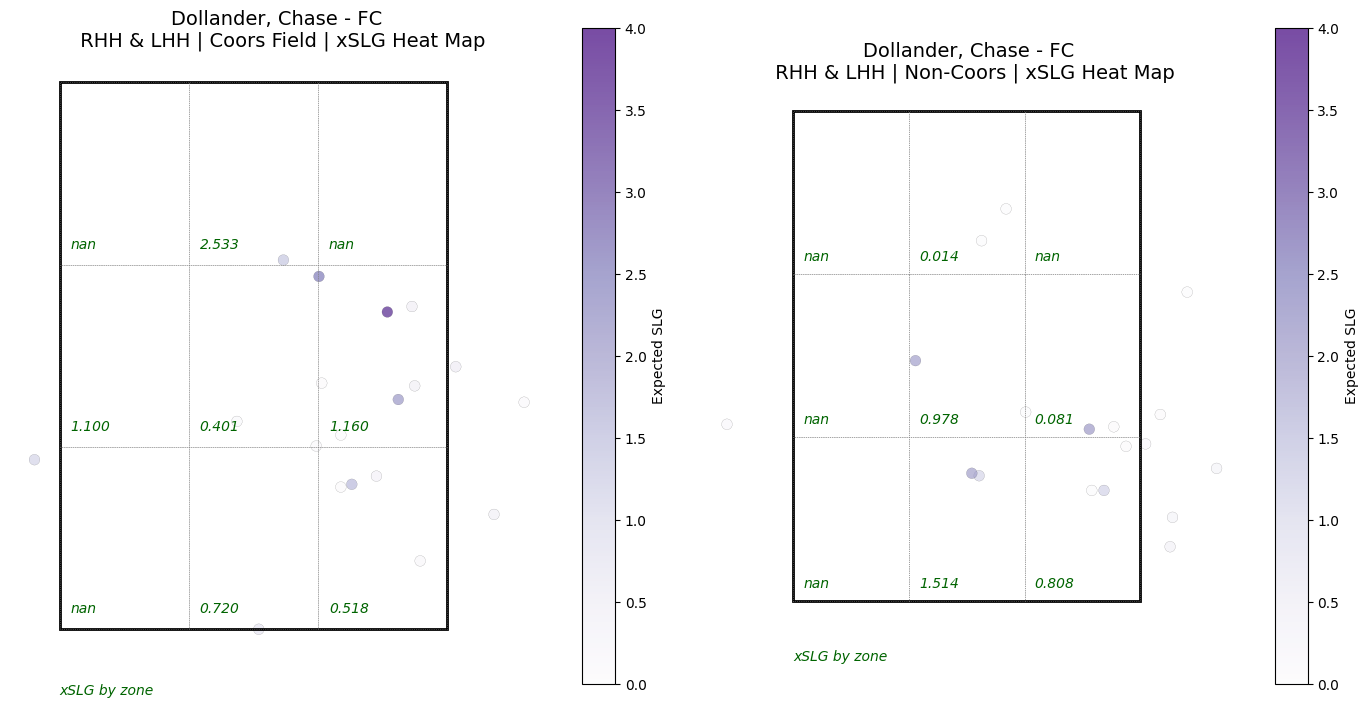

In [ ]:
# Create a 1x2 grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot 1: Coors
plt.sca(ax1)
plot_slg_heatmap_comp(df, "Dollander, Chase", "FC", None, 1)

# Plot 2: Away
plt.sca(ax2)
plot_slg_heatmap_comp(df, "Dollander, Chase", "FC", None, 0)

plt.tight_layout()
plt.show()

## <font color="teal">**Create heat map, visualizing Whiff percentage by zone**</font>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import Normalize
from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon

def plot_whiffs_comp(df, player_name, pitch_type, stand=None, coors_filter=None):
    """
    Plot a plate heat map for a player and pitch type,
    coloring points by estimated SLG on contact.

    Only includes pitches where description == 'hit_into_play'.

    Parameters:
        df : pd.DataFrame
        player_name : str
        pitch_type : str
    """

    # Ensure stand is always a list
    if stand is None:
        stand = ["R","L"]
    elif isinstance(stand, str):
        stand = [stand]

    # Handle coors
    if coors_filter is None:
        coors_filter = [0,1]
    elif isinstance(coors_filter, int):
        coors_filter = [coors_filter]

    # Filter data
    df_plot = df[
        (df['player_name'] == player_name) &
        (df['pitch_type'] == pitch_type) &
        (df['plate_x'] > -2) & (df['plate_x'] < 2) &
        (df['plate_z'] > 1) & (df['plate_z'] < 4) &
        (df['stand'].isin(stand)) &
        (df['coors'].isin(coors_filter))
    ]


    if df_plot.empty:
        print(f"No data for {player_name} / {pitch_type}")
        return


    cmap = ListedColormap(['lightgrey', 'purple'])

    # Scatter
    scatter = plt.scatter(
        df_plot['plate_x'],
        df_plot['plate_z'],
        c=df_plot['whiff'],
        cmap=cmap,
        s=60,
        alpha=0.7,
        edgecolor='black',
        linewidth=0.1
    )


    # Zone whiff style
    text_style = dict(
    ha='left',
    va='top',
    fontsize=12,
    fontstyle='italic',
    fontweight='bold',
    color='darkgreen'
    )

    # Strike zone
    plate_half_width = 17 / 12 / 2
    zone_bottom = 1.5
    zone_top = 3.5
    strike_zone = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width,
        zone_top - zone_bottom,
        linewidth=2,
        edgecolor='Black',
        facecolor='none'
    )

    zone1 = patches.Rectangle(
        (-plate_half_width, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone2 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone3 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + 2 *(zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone4 = patches.Rectangle(
        (-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone5 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone6 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom + (zone_top - zone_bottom) / 3),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone7 = patches.Rectangle(
        (-plate_half_width, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone8 = patches.Rectangle(
        (-plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    zone9 = patches.Rectangle(
        (plate_half_width / 3, zone_bottom),
        2 * plate_half_width / 3,
        (zone_top - zone_bottom) / 3,
        edgecolor='Grey', facecolor='none', linewidth=.5, linestyle=':'
    )

    # Outside Zones
    zone11_coords = [
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom)],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom)],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone11 = Polygon(zone11_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone12_coords = [
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom) + .2],
        [0, zone_bottom + (zone_top - zone_bottom)],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom)],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone12 = Polygon(zone12_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone13_coords = [
        [plate_half_width + .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [plate_half_width + .2, zone_bottom - .2],
        [0, zone_bottom - .2],
        [0, zone_bottom],
        [plate_half_width, zone_bottom],
        [plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone13 = Polygon(zone13_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    zone14_coords = [
        [-plate_half_width - .2, zone_bottom + (zone_top - zone_bottom) / 2],
        [-plate_half_width - .2, zone_bottom - .2],
        [0, zone_bottom - .2],
        [0, zone_bottom],
        [-plate_half_width, zone_bottom],
        [-plate_half_width, zone_bottom + (zone_top - zone_bottom) / 2]
    ]

    zone14 = Polygon(zone14_coords, closed=True, edgecolor='Black', facecolor='none', linewidth=.57, linestyle='-')

    # Collect Zone Whiffs
    zone_whiff_perc = {}

    for i in range(1, 15):
        avg_slg = (
            df_plot[df_plot["zone"] == i]["whiff"].mean()
        )
        zone_whiff_perc[i] = round(avg_slg, 3)

    plt.gca().add_patch(strike_zone)
    plt.gca().add_patch(zone1)
    plt.gca().add_patch(zone2)
    plt.gca().add_patch(zone3)
    plt.gca().add_patch(zone4)
    plt.gca().add_patch(zone5)
    plt.gca().add_patch(zone6)
    plt.gca().add_patch(zone7)
    plt.gca().add_patch(zone8)
    plt.gca().add_patch(zone9)
    plt.gca().add_patch(zone11)
    plt.gca().add_patch(zone12)
    plt.gca().add_patch(zone13)
    plt.gca().add_patch(zone14)

    plt.text(
    -plate_half_width + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[1]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width / 3 + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[2]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width / 3  + 0.04, 0.12 + zone_bottom + 2 *(zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[3]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.12 +  zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[4]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.12 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[5]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.12 + zone_bottom + (zone_top - zone_bottom) / 3,
    f"{zone_whiff_perc[6]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width + 0.04, 0.12 + zone_bottom,
    f"{zone_whiff_perc[7]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + -plate_half_width / 3, 0.12 + zone_bottom,
    f"{zone_whiff_perc[8]:.3f}",
    **text_style
    )

    plt.text(
    0.04 + plate_half_width / 3, 0.12 + zone_bottom,
    f"{zone_whiff_perc[9]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.15, zone_top + 0.15,
    f"{zone_whiff_perc[11]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width - 0.19, zone_top + 0.15,
    f"{zone_whiff_perc[12]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.15, zone_bottom - 0.08,
    f"{zone_whiff_perc[13]:.3f}",
    **text_style
    )

    plt.text(
    plate_half_width - 0.18, zone_bottom - 0.08,
    f"{zone_whiff_perc[14]:.3f}",
    **text_style
    )

    plt.text(
    -plate_half_width - 0.20, zone_bottom - 0.40,
    "Whiff % by zone",
    **text_style
    )



    # Formatting
    # Stand label
    if stand == ["R", "L"]:
        stand_label = "RHH & LHH"
    elif stand == ["R"]:
        stand_label = "RHH"
    elif stand == ["L"]:
        stand_label = "LHH"
    else:
        stand_label = "Mixed"

    # Coors label
    if coors_filter == [0,1]:
        coors_label = "All Parks"
    elif coors_filter == [1]:
        coors_label = "Coors Field"
    elif coors_filter == [0]:
        coors_label = "Non-Coors"
    else:
        coors_label = ""

    # Pitching label
    if pitch_type == "FF":
        pitch_type = "Fastball"
    elif pitch_type == "CU":
        pitch_type = "Curveball"


    plt.axis('off')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"{player_name} - {pitch_type} \n {stand_label} | {coors_label} | Whiffs by zone", fontsize=14)



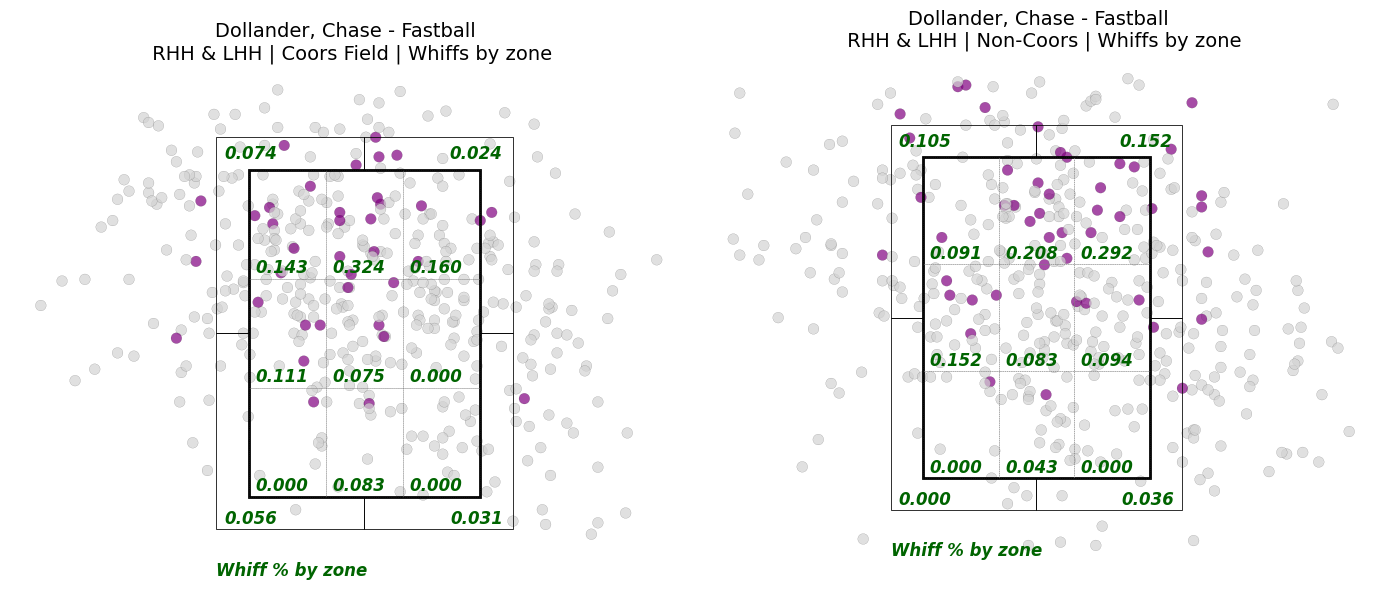

In [ ]:
# Create a 1x2 grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Plot 1: Coors
plt.sca(ax1)
plot_whiffs_comp(df, "Dollander, Chase", "FF", None, 1)

# Plot 2: Away
plt.sca(ax2)
plot_whiffs_comp(df, "Dollander, Chase", "FF", None, 0)

plt.tight_layout()
plt.show()